<a href="https://colab.research.google.com/github/athulskrish/google_play_store_review/blob/main/Google_playstore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
play_store=pd.read_csv('/content/drive/MyDrive/UML/google play/googleplaystore.csv')

In [ ]:
play_store.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
play_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
play_store.Reviews.describe()

,Reviews
count,10841
unique,6002
top,0
freq,596


In [ ]:
for column in play_store:
  print(column,play_store[column].isnull().sum())


App 0
Category 0
Rating 1474
Reviews 0
Size 0
Installs 0
Type 1
Price 0
Content Rating 1
Genres 0
Last Updated 0
Current Ver 8
Android Ver 3


In [ ]:
play_store.shape

(10841, 13)

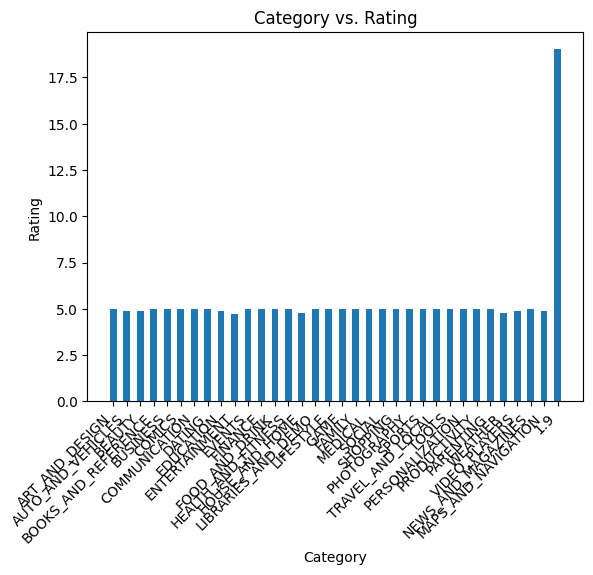

In [ ]:
import matplotlib.pyplot as plt
plt.bar(play_store['Category'], play_store['Rating'],width=.5)
plt.xlabel('Category')
plt.ylabel('Rating')
plt.title('Category vs. Rating')
# plt.figure(figsize=(100, 20))
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
play_store.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [ ]:
play_store.Type.unique()
play_store['Type_Cleaned']= play_store['Type'].str.replace("0","Free")
play_store['Type_Cleaned'].fillna(0, inplace=True)

play_store['Type_Cleaned'] = play_store['Type_Cleaned'].astype(str)



<ipython-input-10-6548f8c7f1b8>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  play_store['Type_Cleaned'].fillna(0, inplace=True)


In [ ]:
play_store.Installs.unique()
play_store['Installs_Cleaned'] = play_store['Installs'].str.replace(',', '')
play_store['Installs_Cleaned'] = play_store['Installs_Cleaned'].str.replace('+', '')
play_store['Installs_Cleaned'] = play_store['Installs_Cleaned'].str.replace('Free', '0')
play_store['Installs_Cleaned'] = pd.to_numeric(play_store['Installs_Cleaned'], errors='coerce')
play_store['Installs_Cleaned'].fillna(0, inplace=True)
play_store['Installs_Cleaned'] = play_store['Installs_Cleaned'].astype(int)


<ipython-input-11-cd968e5c6f08>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  play_store['Installs_Cleaned'].fillna(0, inplace=True)


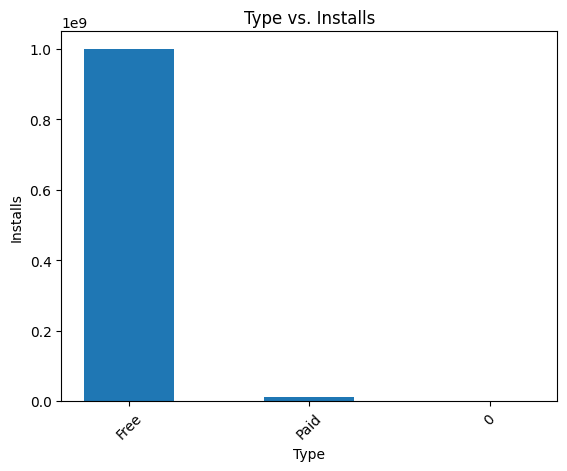

In [ ]:
plt.bar(play_store['Type_Cleaned'], play_store['Installs_Cleaned'],width=.5)
plt.xlabel('Type')
plt.ylabel('Installs')
plt.title('Type vs. Installs')
# plt.figure(figsize=(100, 20))
plt.xticks(rotation=45)
plt.show()

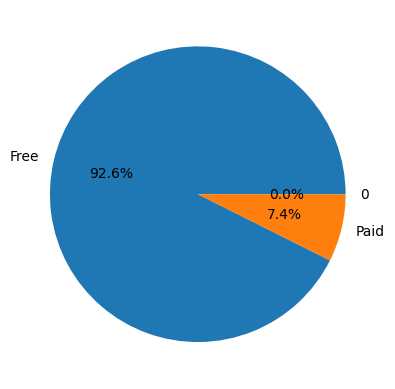

In [ ]:
plt.pie(play_store['Type_Cleaned'].value_counts(), labels=play_store['Type_Cleaned'].value_counts().index, autopct='%1.1f%%')
plt.show()

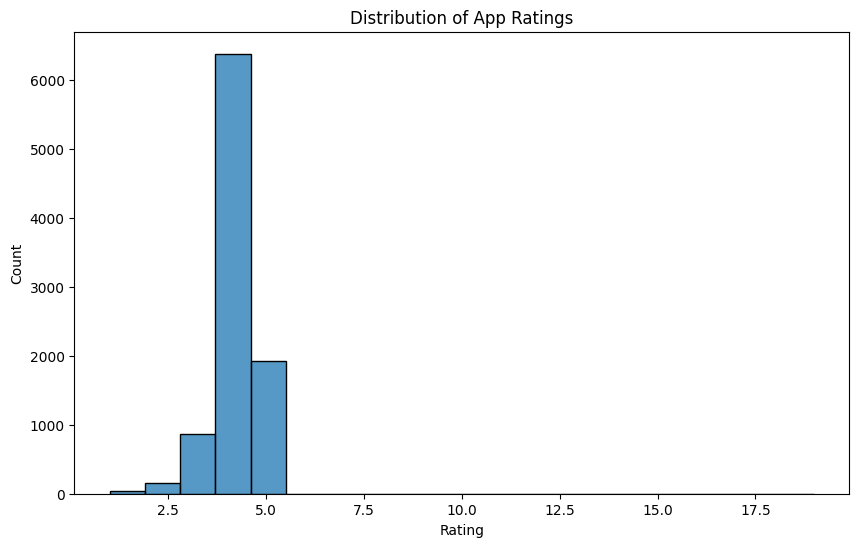

In [ ]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(play_store['Rating'], bins=20, kde=False)

plt.title('Distribution of App Ratings')
plt.show()

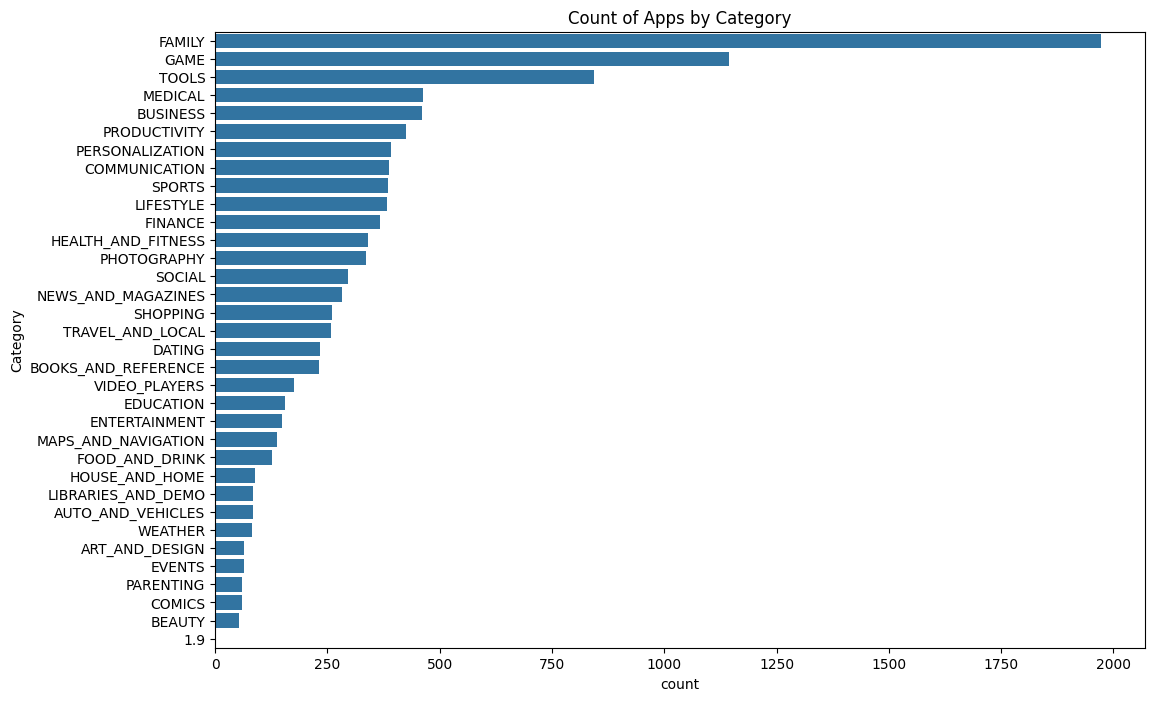

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(y='Category', data=play_store,
order=play_store['Category'].value_counts().index)
plt.title('Count of Apps by Category')
plt.show()

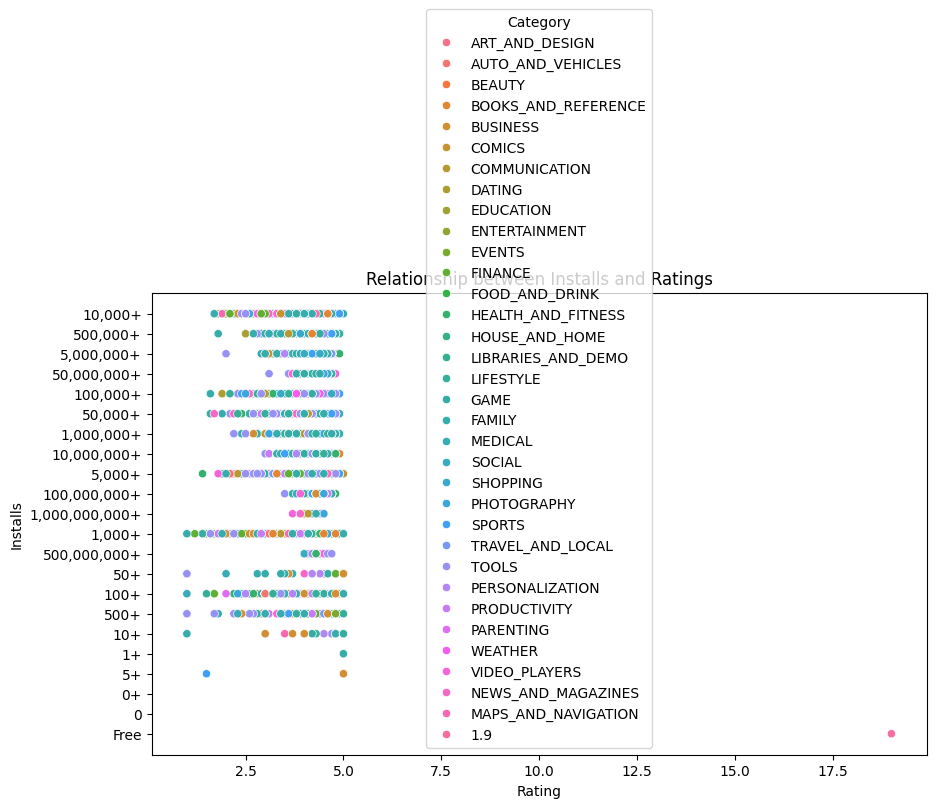

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rating', y='Installs', hue='Category',
data=play_store)
plt.title('Relationship between Installs and Ratings')
plt.show()

In [ ]:
avg_rating_by_category =play_store.groupby('Category')['Rating'].mean().sort_values(ascending=False)
print(avg_rating_by_category)

Category
1.9                    19.000000
EVENTS                  4.435556
EDUCATION               4.389032
ART_AND_DESIGN          4.358065
BOOKS_AND_REFERENCE     4.346067
PERSONALIZATION         4.335987
PARENTING               4.300000
GAME                    4.286326
BEAUTY                  4.278571
HEALTH_AND_FITNESS      4.277104
SHOPPING                4.259664
SOCIAL                  4.255598
WEATHER                 4.244000
SPORTS                  4.223511
PRODUCTIVITY            4.211396
HOUSE_AND_HOME          4.197368
FAMILY                  4.192272
PHOTOGRAPHY             4.192114
AUTO_AND_VEHICLES       4.190411
MEDICAL                 4.189143
LIBRARIES_AND_DEMO      4.178462
FOOD_AND_DRINK          4.166972
COMMUNICATION           4.158537
COMICS                  4.155172
NEWS_AND_MAGAZINES      4.132189
FINANCE                 4.131889
ENTERTAINMENT           4.126174
BUSINESS                4.121452
TRAVEL_AND_LOCAL        4.109292
LIFESTYLE               4.094904
V

In [ ]:
most_installed_apps = play_store[['App',
'Installs']].sort_values(by='Installs',
ascending=False).head(10)
print(most_installed_apps)

                                               App      Installs
10472      Life Made WI-Fi Touchscreen Photo Frame          Free
420    UC Browser - Fast Download Private & Secure  500,000,000+
474                    LINE: Free Calls & Messages  500,000,000+
3767                  Flipboard: News For Our Time  500,000,000+
3574                                   Cloud Print  500,000,000+
3326                  Gboard - the Google Keyboard  500,000,000+
431                                Viber Messenger  500,000,000+
4222                 imo free video calls and chat  500,000,000+
3235                              Google Translate  500,000,000+
1842                              Candy Crush Saga  500,000,000+


In [ ]:
top_genres = play_store['Genres'].value_counts().head(5)

print("top_genres",top_genres)

top_genres Genres
Tools            842
Entertainment    623
Education        549
Medical          463
Business         460
Name: count, dtype: int64


In [ ]:
top_genres = play_store['Genres'].value_counts().tail(5)

print("low_genres",top_genres)

low_genres Genres
Arcade;Pretend Play       1
Card;Brain Games          1
Lifestyle;Pretend Play    1
Comics;Creativity         1
Strategy;Creativity       1
Name: count, dtype: int64


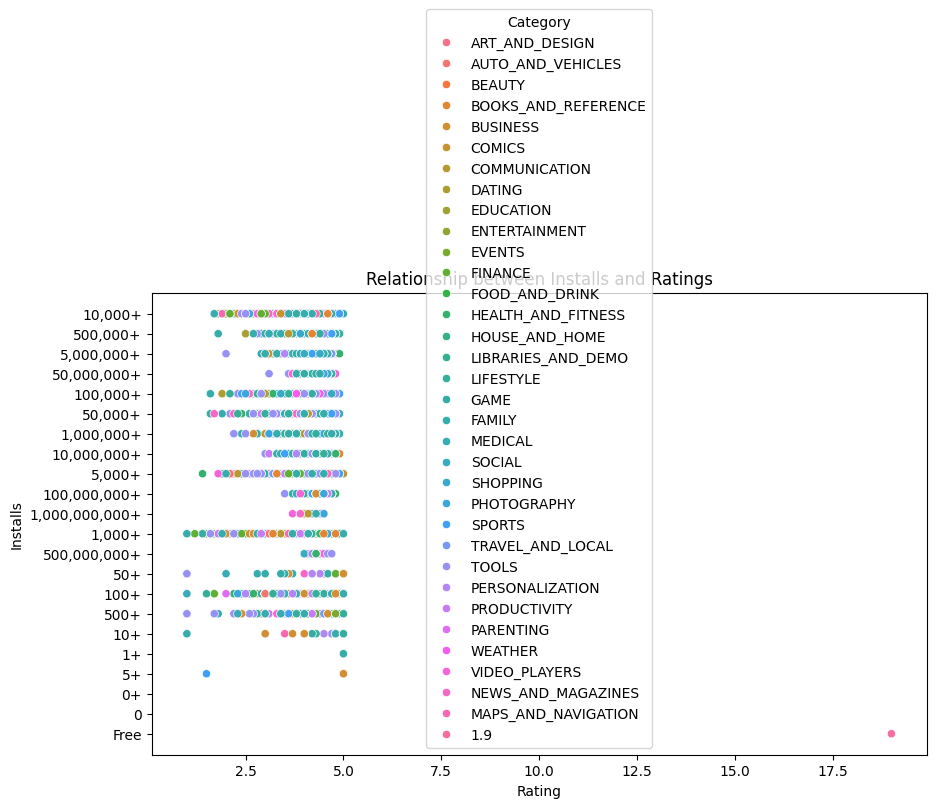

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rating', y='Installs', hue='Category',
data=play_store)
plt.title('Relationship between Installs and Ratings')
plt.show()